## Ejercicio de Feedback: Clustering

# Introducción y planteamiento del problema

"**Ayuda Internacional**" es una ONG humanitaria internacional comprometida con la lucha contra la pobreza y con proporcionar a las personas de países subdesarrollados servicios básicos y ayuda en tiempos de desastres y calamidades naturales. Esta ONG ha logrado recaudar aproximadamente 10 millones de dólares. Este dinero debe ahora asignarse de manera estratégica y eficaz. Por lo tanto, para decidir la selección de los países que más necesitan ayuda, se deben tomar decisiones basadas en datos.

En consecuencia, resulta necesario **categorizar los países utilizando factores socioeconómicos y de salud** que determinen el desarrollo general de cada país. Basándose en estos grupos de países, definidos por sus condiciones, se distribuirán los fondos para brindar asistencia durante desastres y calamidades naturales. Este es un caso claro de clustering, donde se requiere crear grupos de países basados en las diferentes características presentes.

**Objetivo**:


*   Agrupar países en función de características numéricas socioeconómicas.
*   Determinar qué grupos de países requieren ayuda y en qué grado



## Nuestro conjunto de datos




* **country**: Nombre del país.
* **child_mort**: Muertes de niños menores de 5 años por cada 1000 nacidos vivos.
* **exports**: Exportaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **health**: Gasto total en salud per cápita, expresado como porcentaje del PIB per cápita.
* **imports**: Importaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **Income**: Ingreso neto por persona.
* **Inflation**: Tasa de crecimiento anual del PIB total.
* **life_expec**: Número promedio de años que un recién nacido viviría si se mantienen los patrones actuales de mortalidad.
* **total_fer**: Número de hijos que nacerían por mujer si las tasas actuales de fertilidad por edad permanecen constantes.
* **gdpp**: PIB per cápita, calculado como el PIB total dividido entre la población total.




## 1 Importación de librerías

In [1]:
import plotly.express as px
import kaleido
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import numpy as np

# Clusterización
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# Visualización en 3D
import plotly as py
import plotly.graph_objs as go

## 2 Análisis Exploratorio de los datos

**Ejercicio 1** - Llevar a cabo un procedimiento de EDA para obtener información acerca de los datos:

*  Declara el tamaño del dataset y muestra algunos registros por pantalla. Muestra los estadísticos (media, desviación típica, min, max...) relevantes de cada una de las variables. Observando el tipo de características, ¿podemos usarlas todas en un algoritmo de agrupación?

*  Analiza la distribución de cada una de las variables mediante gráficas de densidad y boxplots (se valora utilizar el mínimo código posible para mostrar todas las gráficas). ¿Están bien distribuidas las variables? ¿Qué podemos comentar de este análisis?



In [2]:
# Cargo el dataset
df = pd.read_csv('Country-data.csv')

# Muestro 15 registros con head para verificar que se ha cargado correctamente y ver el aspecto de las variables
df.head(15)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [3]:
# Declaro el número de filas (países) y columnas (variables) del dataset
df.shape

(167, 10)

In [4]:
# Muestro los estadísticos descriptivos más relevantes de cada variable para hacerme una idea de la escala
# y distribución de cada una de ellas
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
# Observo si hay nulos y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


No podríamos usarlas todas en el algoritmo de agrupación, ya que para los algoritmos de agrupación basados en distancia se requieren valores numéricos al estar calculando la distancia euclidiana, y 'country' es una variable categórica, por lo que se usará simplemente como etiqueta para cada uno de las 9 variables socioeconómicas y de salud (las numéricas). Aunque se podría tratar de pasar esta variable categórica a numérica a través de distintas técnicas, en este caso de uso no aportaría información úlil para la agrupación de los datos al tratarse de una variable que identifica de manera única cada país.

/tmp/ipykernel_38531/783677955.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax=axes2[i])
/tmp/ipykernel_38531/783677955.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], ax=axes2[i])
/tmp/ipykernel_38531/783677955.py:15: UserWarning: 

`distplot` is a deprecated func

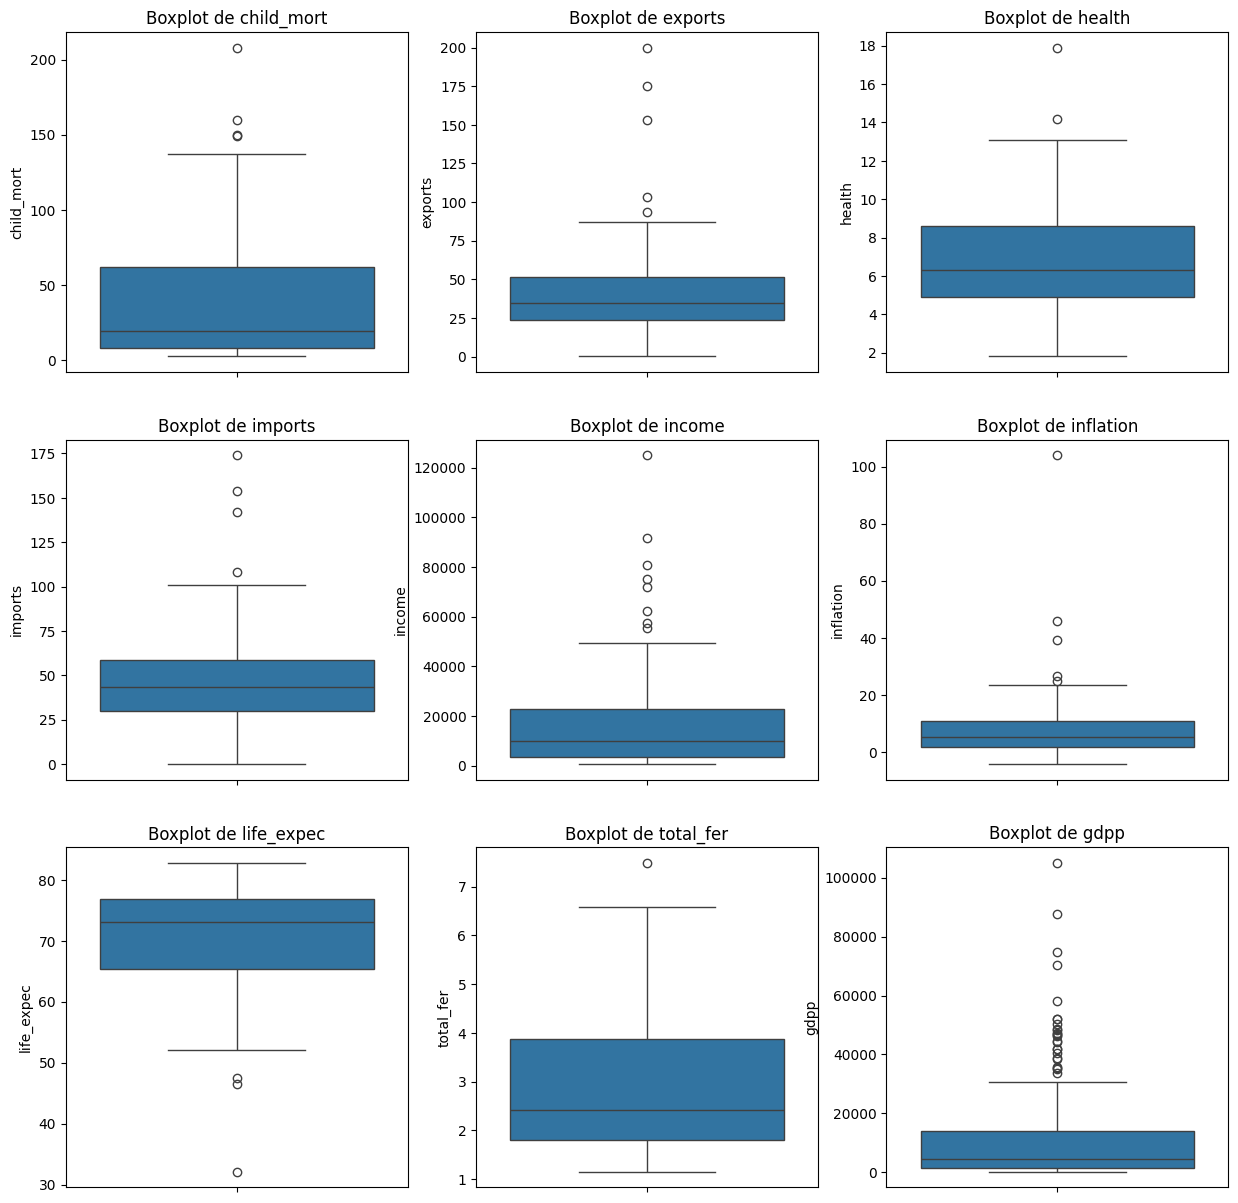

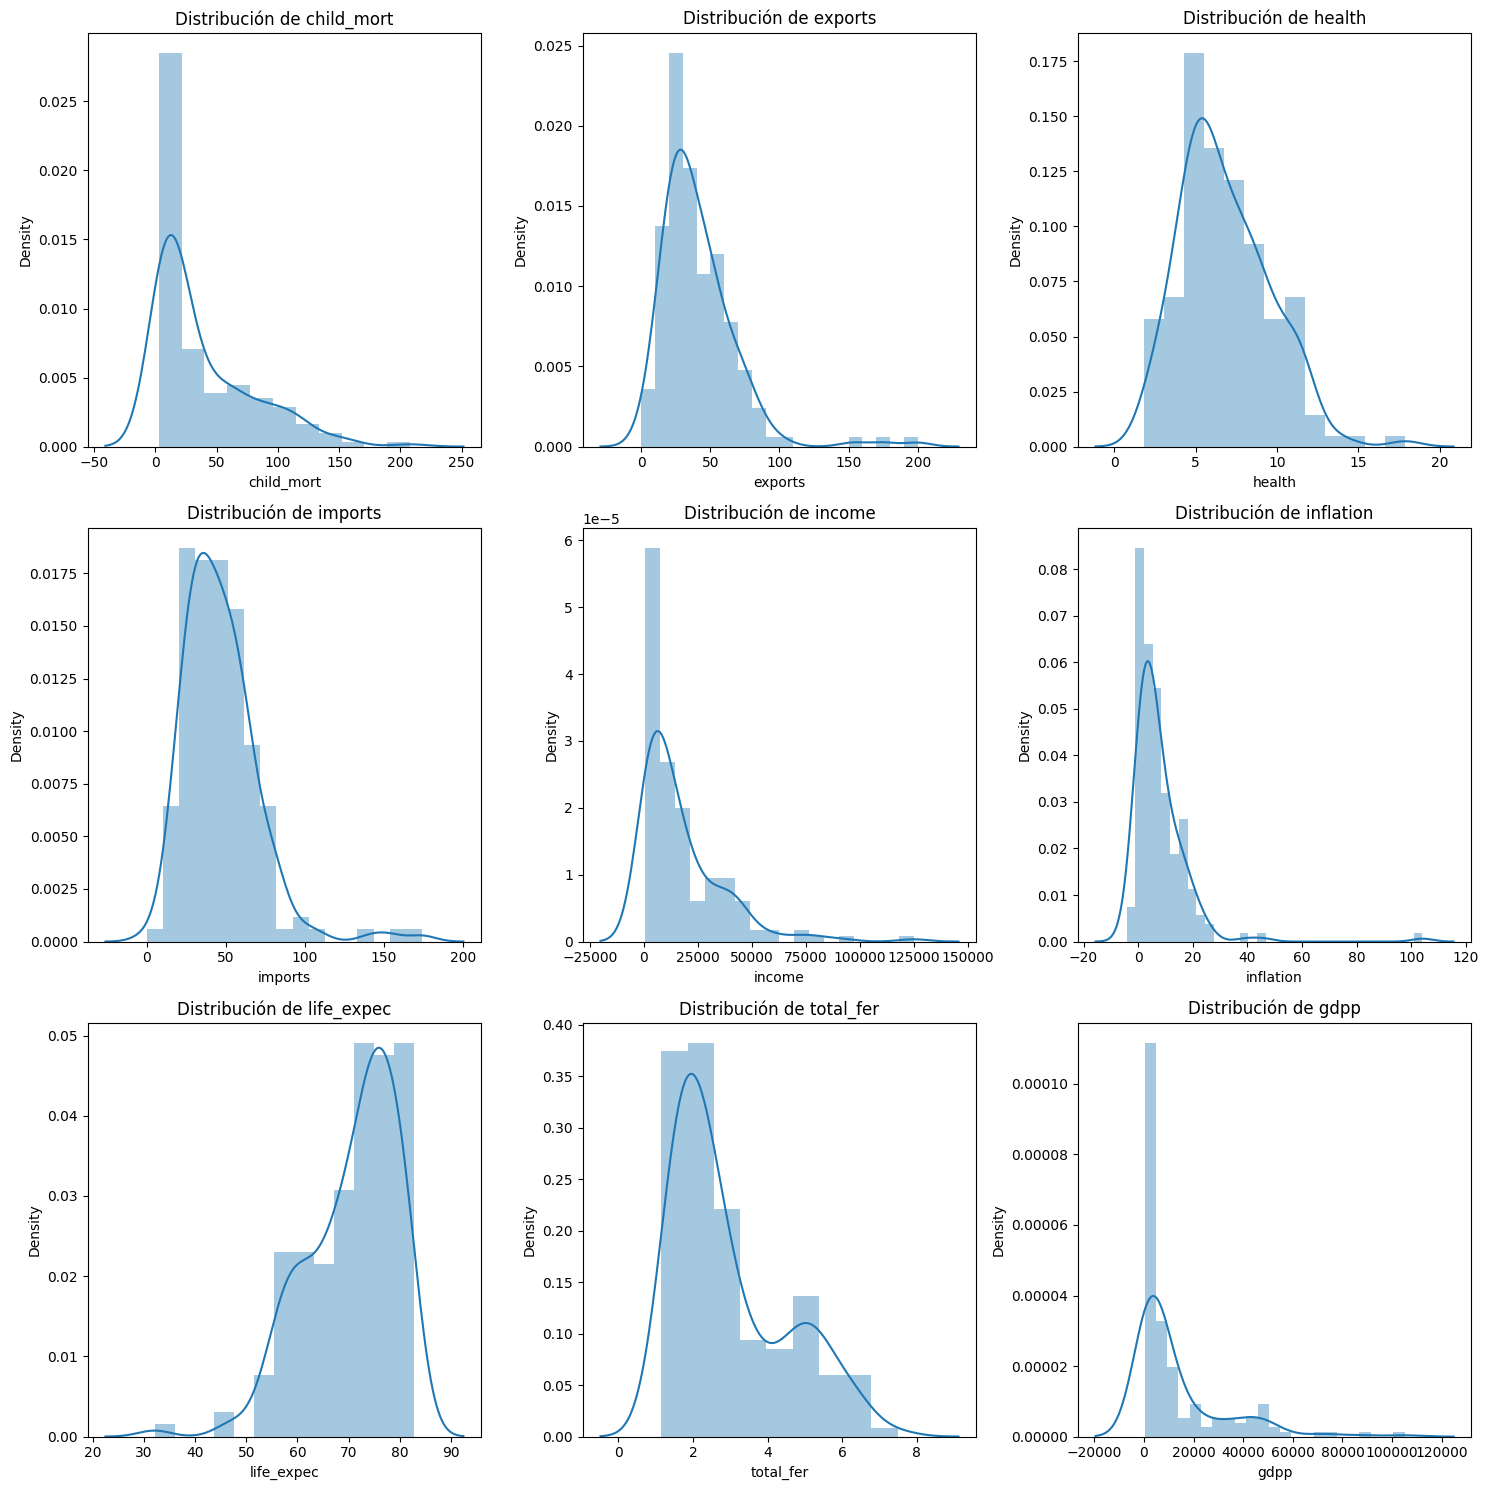

In [6]:
# Creo una lista de las variables de utilidad que voy a representar y elimino la variable categórica 'country'
columns = df.columns.to_list()
columns.remove('country')

# Creo dos figuras con sus ejes donde representaré un boxplot y un distplot para cada variable
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
fig2, axes2 = plt.subplots(3, 3, figsize=(15, 15))
axes2 = axes2.flatten()

for i, col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

    sns.distplot(df[col], ax=axes2[i])
    axes2[i].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

Observando los gráficos generados, es posible concluir que no hay distribución normal, y que por tanto las variables no están bien distribuídas, ya que la mayoría presenta una asimetría positiva, como es el caso de las variables relacionadas con el ámbito financiero, como `gdpp`, `Income` e `Inflation`, lo que está relacionado con la desigual concentración de la riqueza por parte de los países, donde se aprecian valores atípicos que denotan valores extremadamente altos frente a la mayoría, que tienen valores bajos. Una excepción de esto es la variable `life_expec`, que muestra una asimetría negativa, indicando que la esperanza de vida baja es una excepción.

Los valores obtenidos reflejan claramente una desigualdad global, donde principalmente los valores atípicos corresponden al primer mundo mientras que la mayoría de los datos se corresponden con países en vías de desarrollo.

También es de destacar la diferencia de escalado entre las variables, que se observó también en los estadísticos descriptivos principales mostrados anteriormente, donde no solo existe una variabilidad muy alta en el rango de valores dentro de una variable, sino también en las diferentes escalas utilizadas en las distintas variables.

## 3 Extracción de las características

**Ejercicio 2** - Realizaremos transformaciones en nuestros datos en crudo para obtener las variables con las que realizar el clustering.

*   Muestra la matriz de correlaciones por pantalla y comenta resumidamente sus conclusiones.

*   Vamos a **agrupar todas nuestras nueve variables en tres grandes indicadores** diferentes: **Salud** (4 variables), **Comercio** (2 variables) y **Finanzas** (3 variables). Definir las agrupaciones en base a lo que significa cada variable. Para construir cada uno de los indicadores, sumaremos cada una de las variables agrupadas en ese indicador dividida por su media (Por ejemplo: Comercio = (variable1/media_variable1) + (variable2/media_variable2)

* Una vez construidos los indicadores, tenemos que asegurarnos que los tres estén a la **misma escala**. Para ello tenemos que decidirnos por la **estandarización** o la **normalización**, ambas funciones nativas de SKLearn. Visualiza la distribución de los 3 grandes indicadores, decide que método emplear (estandarización/normalización) y aplícalo a nuestros datos.






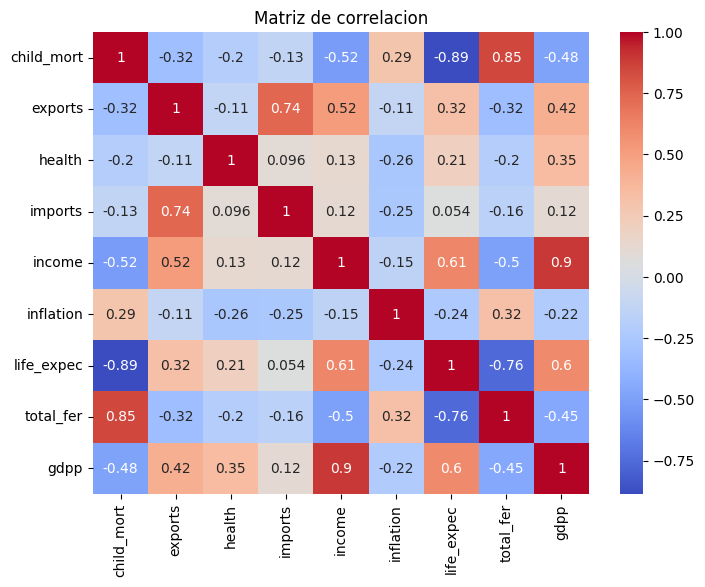

In [7]:
dataframe = pd.DataFrame(df, columns=columns)

# Obtengo la matriz de correlación
matrix = dataframe.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlacion')
plt.show()

Obtenida la matriz de correlaciones se han dividido las conclusiones en función de su correlación:
- Correlaciones positivas: En este caso destacan las variables `Income` y `gdpp`, con una correlación altísima, indicando prosperidad económica. En segundo lugar, se encuentran las variables `child_mort` y `total_fer` con una correlación muy alta, lo que indica que en países con natalidad muy alta, la mortalidad infantil es significativamente mayor. Por último, se encuentran las variables `exports` e `imports`, que muestran una fuerte correlación positiva, ya que el volumen de comercio internacional va de la mano en ambas direcciones.

- Correlaciones negativas: En este caso destacan las variables `child_mort` y `life_expec`, que indican que en aquellos países donde la mortalidad infantil es más alta, la esperanza de vida total es más baja. Por último, las variables `gdpp`/`Income` y `child_mort`/`total_fer` presentan una correlación negativa, lo que explica que cuanto más rico es un país, menor es su mortalidad infantil y menor es su tasa de natalidad.

In [8]:
# Dividimos las variables en agrupaciones, reduciendo así la dimensionalidad del dataset
finanzas = ['gdpp', 'inflation', 'income']
salud = ['life_expec', 'child_mort', 'total_fer', 'health']
comercio = ['imports', 'exports']

# Creo un nuevo DataFrame para los indicadores
indicators_df = pd.DataFrame()
# Añado la columna de países para mantener la referencia
indicators_df['country'] = df['country']

# Para construir cada indicador sumo/resto (dependiendo de la correlación anterior) cada una de las variables 
# agrupadas en ese indicador, dividida por su media
indicators_df['finanzas'] = (df['gdpp'] / df['gdpp'].mean()) + (df['income'] / df['income'].mean()) - (df['inflation'] / df['inflation'].mean())
indicators_df['salud'] = (df['life_expec'] / df['life_expec'].mean()) - (df['child_mort'] / df['child_mort'].mean()) - (df['total_fer'] / df['total_fer'].mean()) + (df['health'] / df['health'].mean())
indicators_df['comercio'] = (df['imports'] / df['imports'].mean()) + (df['exports'] / df['exports'].mean())

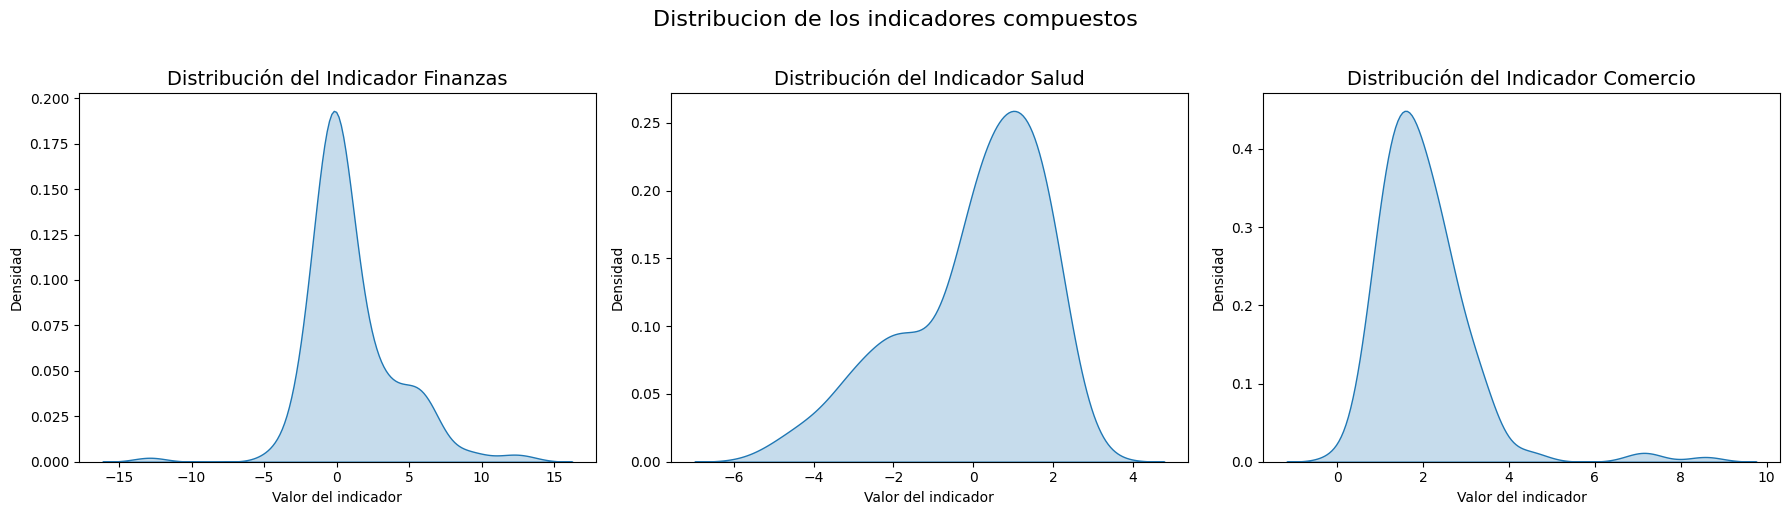

In [9]:
# Cojo las columnas de interés para crear la visualización de los indicadores
indicator_cols = ['finanzas', 'salud', 'comercio']

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    sns.kdeplot(indicators_df[col], ax=axes[i], fill=True)
    axes[i].set_title(f'Distribución del Indicador {col.capitalize()}', fontsize=14)
    axes[i].set_xlabel('Valor del indicador')
    axes[i].set_ylabel('Densidad')

fig.suptitle('Distribucion de los indicadores compuestos', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Observando las distribuciones de los indicadores se empleará el método de estandarización, ya que es la opción más adecuada cuando se trabaja con indicadores que presentan una gran variabilidad y outliers. Esta técnica transforma los datos en una distribución con media 0 y desviación típica 1, y es preferible cuando existen outliers o distribuciones muy asimétricas, cuando se usan técnicas basadas en la distancia euclídea y cuando se require que todas las variables aporten por igual independientemente de su magnitud original, como es este caso en concreto.

Por otra parte, la normalización se ve afectada por valores muy extremos, que comprimen la escala y hacen que la mayoría de los países queden muy juntos, por lo que no se trata del método adecuado en este caso.

In [10]:
# Descomentar celda y comentar la siguiente para ver qué resultados daría MinMaxScaler

# from sklearn.preprocessing import MinMaxScaler

# Inicializo el normalizador
# scaler = MinMaxScaler()

# # Aplico fit y transformo solo las columnas de indicadores.
# # Creo un DataFrame para almacenar los valores escalados.
# indicadores_escalados = pd.DataFrame(
#     scaler.fit_transform(indicators_df[indicator_cols]),
#     columns=indicator_cols
# )

# indicadores_escalados.index = indicators_df.index
# indicadores_escalados['country'] = indicators_df['country']

# X = indicadores_escalados.drop('country', axis=1)

In [11]:
# Inicializo el estandarizador
scaler = StandardScaler()

# Aplico fit y transformo solo las columnas de indicadores.
# Creo un DataFrame para almacenar los valores escalados.
indicadores_escalados = pd.DataFrame(
    scaler.fit_transform(indicators_df[indicator_cols]),
    columns=indicator_cols
)

# Mantengo los índices originales
indicadores_escalados.index = indicators_df.index

# Añado el nombre del país para referencia
indicadores_escalados['country'] = indicators_df['country']

# X será el DataFrame final solo con los indicadores escalados
X = indicadores_escalados.drop('country', axis=1)


## 4 Entrenamiento y evaluación del modelo

**Ejercicio 3**: Una vez tenemos los datos estandarizados, procedemos a aplicar nuestro método de agrupación.

*  **Selección del algoritmo de clustering**: Argumentar de manera razonada, teniendo en cuenta nuestro problema concreto, que método de agrupación es mejor aplicar en este caso. Existe uno claramente diferenciado.

* **Ajuste de hiperparámetro/s**: Una vez seleccionado el modelo, ajusta los hiperparámetro/s para decidir el o los mejores valores del mismo. Recuerda utilizar todas las técnicas vistas en clase y hacer un análisis completo de la situación para poder tomar la decisión con toda la información disponible. La elección de los valor/es de los hiperparámetros deben estar justificados con gran profundidad y evidencias.

* **Evaluación de la agrupación**: Utiliza métricas vistas en clase y la representación visual de la agrupación final realizada para valorar la calidad de la misma. Usa las librerías 2D y 3D vistas en las prácticas.





### Selección del algoritmo de clustering

El algoritmo de clustering a emplear en este caso será K-means, puesto que se requiere la agrupación de países en clústeres para determinar el nivel de ayuda que va a recibir cada uno, de forma que se espera dividir los mismos en clústers esféricos y de tamaño similar, buscando minimizar la distancia intra-clúster y maximizar la distancia inter-clúster, o lo que es lo mismo, queremos asegurarnos de que cada clúster esté bien diferenciado. Además, se tiene un dataset numérico y escalado, lo que favorece la eficiencia computacional de este algoritmo.

### Ajuste de hiperparámetros (Selección de K)

Para determinar el valor del hiperparámetro K correspondiente al número de clústers, se empleará el método del codo. Para ello, se realizará la ejecución del algoritmo para diferentes valores de K y se eligirá aquel para el cual la suma de los cuadrados intra-clúster se estabiliza.

Para hacer este método es necesario ejecutar K-means con diferentes valores de K, por lo que habrá que escoger una partición inicial, en mi caso mediante la inicialización K-means++, que selecciona k centroides de manera estratégica, eligiendo el primer centroide de forma aleatoria y luego seleccionando los centroides restantes basándose en la distancia respecto a los previamente elegidos. Este enfoque ayuda a evitar agrupamientos subóptimos y mejora la calidad de agrupamiento en comparación con la inicialización aleatoria en el algoritmo K-means.

### Método del codo

In [12]:
# Defino el diccionario donde guardaré la suma de cuadrados
sum_of_sqr_dts = {}

for k in range(1, 10):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000)
    km = km.fit(X)
    sum_of_sqr_dts[k] = km.inertia_ # Nos da la suma de cuadrados intra-clúster

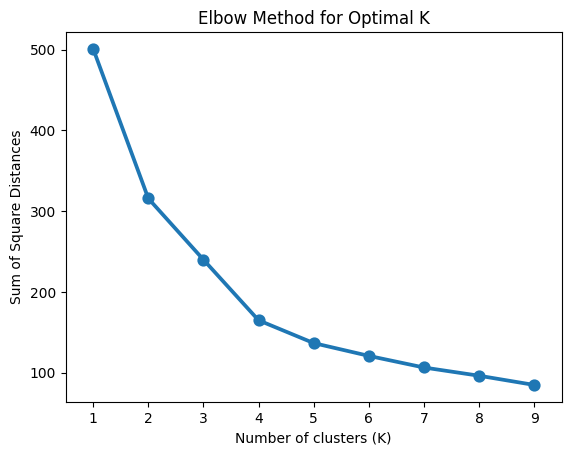

In [13]:
sns.pointplot(x=list(sum_of_sqr_dts.keys()), y=list(sum_of_sqr_dts.values()))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Square Distances")
plt.title("Elbow Method for Optimal K")
plt.show()

Obervando el gráfico anterior es posible comprobar cómo la curva disminuye significativamente hasta K = 4, donde la disminución se ve mucho menos pronunciada, lo que nos sugiere que podría ser el
número óptimo de clústers. De ser así, podríamos diferenciar 4 claros grupos: los países del primer mundo, países en vías de desarrollo, países del tercer mundo vulnerables y países del tercer mundo en emergencia.

In [14]:
# Creo el modelo para K = 4 y lo ajusto
Model = KMeans(n_clusters=4, 
               init='k-means++', 
               max_iter=1000)
Model.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,1000
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [15]:
# Imprimo las etiquetas para ver la asignación de cada observación a cada clúster
print("Labels", Model.labels_)

Labels [1 2 2 1 2 2 2 0 0 2 0 2 1 2 2 0 2 1 2 2 2 2 2 0 2 1 1 2 1 0 2 1 1 2 2 2 1
 1 1 2 1 2 0 0 0 2 2 2 2 1 1 2 2 0 0 1 1 2 0 1 0 2 2 1 1 2 1 2 0 1 2 2 2 0
 0 0 2 0 2 2 1 2 0 2 1 2 2 2 1 2 2 3 2 1 1 2 2 1 3 1 2 2 2 2 2 2 1 1 2 1 0
 0 1 1 0 2 1 2 2 2 2 2 0 0 2 2 1 2 2 1 2 2 1 3 2 0 2 2 0 0 2 2 1 2 0 0 1 1
 2 1 1 2 2 2 2 1 2 0 0 0 2 2 2 2 2 1 1]


In [16]:
# Imprimo centroides para ver qué asignación de estimadores ha hecho para cada clúster
print("Centroids", Model.cluster_centers_)

Centroids [[ 1.48121789  0.98701018 -0.01146064]
 [-0.75828035 -1.37651105 -0.48107605]
 [-0.22442084  0.33760746  0.08340325]
 [ 2.26070521  0.90031351  5.10785294]]


Aquí se pueden observar los valores de los centroides, que se corresponden con valores tridimensionales asociados a los indicadores por orden (finanzas, salud y comercio).

### Evaluación con el método de la Silueta

In [17]:
# Le paso estas etiquetas para calcular el silhouette score
labels = Model.labels_
silhouette_score(X, labels)

0.37794155502523097

In [18]:
# Experimento con diferentes valores de K para un valor razonable de iteraciones
# que nos garanticen una convergencia del algoritmo
silhouette = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init=20)
    km = km.fit(X)
    silhouette[k] = silhouette_score(X, km.labels_)

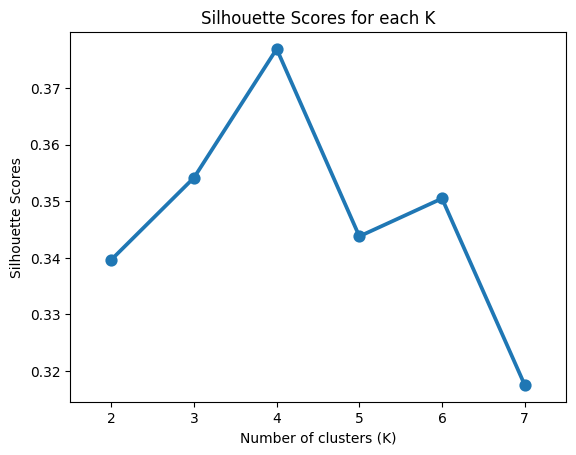

In [19]:
sns.pointplot(x=list(silhouette.keys()), y=list(silhouette.values()))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for each K")
plt.show()

Observando ahora el gráfico de los silhouette scores para cada K, se puede comprobar que dicho coeficiente alcanza su valor más alto para K = 4, lo cual muestra que con 4 grupos los países están matemáticamente mejor definidos y separados entre sí.

### Evaluación con Gap Statistics

Para corroborar mi elección, evalúo además con Gap Statistics, que proporciona un menor grado de subjetividad que el elbow method.

In [20]:
# Defino parámetros de interés para pasarle al algoritmo
n_clusters=3
init='k-means++'
max_iter=1000
n_init= 20

In [21]:
def calculate_gap_statistic(data, refs=None, n_refs=10, max_k=10):
    """
    Calcula el Gap Statistic para el rango de clusters K = [1, max_k].

    Parámetros:
    - data: array numpy de los datos (normalizados)
    - refs: datos de referencia generados aleatoriamente (si es None, se generan internamente)
    - n_refs: número de conjuntos de referencia
    - max_k: máximo número de clusters a evaluar

    Devuelve:
    - gaps: lista con los valores Gap Statistic para cada valor de K
    - deviations: desviaciones estándar de las simulaciones
    """
    if refs is None:
        refs = np.random.uniform(low=np.min(data, axis=0), high=np.max(data, axis=0), size=(data.shape[0] * n_refs, data.shape[1]))

    gaps = []
    deviations = []

    for k in range(1, max_k + 1):
        # Ajuste del modelo KMeans en los datos reales
        kmeans = KMeans(n_clusters=k, init = 'k-means++', n_init =20)
        kmeans.fit(data)
        disp_real = np.mean(np.min(pairwise_distances(data, kmeans.cluster_centers_), axis=1))

        # Ajuste del modelo KMeans en los datos aleatorios
        disp_refs = []
        for i in range(n_refs):
            ref_subset = refs[i * data.shape[0]:(i + 1) * data.shape[0], :]
            kmeans.fit(ref_subset)
            disp_refs.append(np.mean(np.min(pairwise_distances(ref_subset, kmeans.cluster_centers_), axis=1)))

        # Gap Statistic y desviación estándar
        gap = np.log(np.mean(disp_refs)) - np.log(disp_real)
        sd_k = np.sqrt(np.mean((np.log(disp_refs) - np.log(np.mean(disp_refs))) ** 2))
        sk = sd_k * np.sqrt(1 + 1 / n_refs)  # Ajuste por el número de referencias

        gaps.append(gap)
        deviations.append(sk)

    return np.array(gaps), np.array(deviations)

Es el número de conjuntos de datos aleatorios que se generan para estimar la dispersión esperada bajo una distribución aleatoria.
Un mayor número de referencias mejora la precisión en la estimación de la dispersión esperada, pero también aumenta el tiempo de cálculo.

In [22]:
n_refs = 50
max_k = 9

In [23]:
gaps, deviations = calculate_gap_statistic(X, n_refs=n_refs, max_k=max_k)

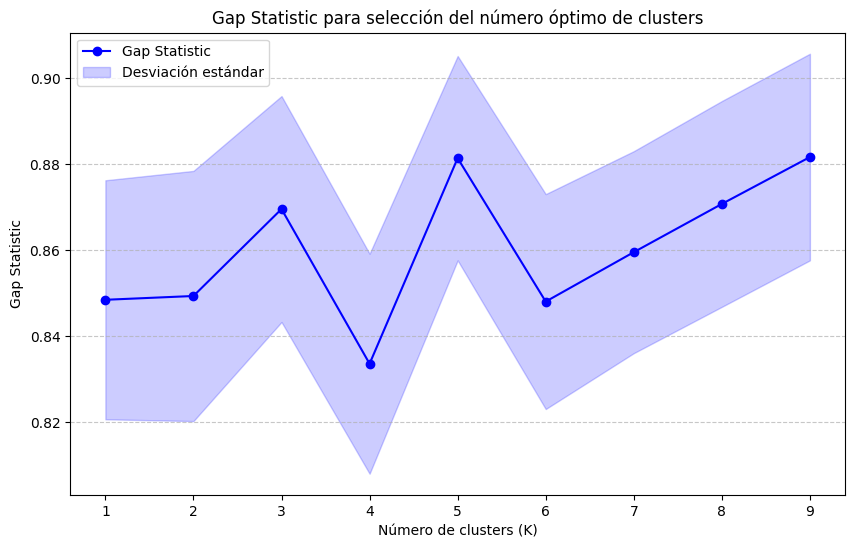

In [24]:
ks = np.arange(1, max_k + 1)
plt.figure(figsize=(10, 6))
plt.plot(ks, gaps, marker='o', linestyle='-', color='blue', label='Gap Statistic')
plt.fill_between(ks, gaps - deviations, gaps + deviations, color='blue', alpha=0.2, label='Desviación estándar')
plt.title('Gap Statistic para selección del número óptimo de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Gap Statistic')
plt.xticks(ks)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Aunque este método nos sugiere un valor de K = 5, dado que los dos métodos anteriores nos han mostrado un buen valor de K para el caso de estudio y K = 5 no es un valor con una diferencia crítica, he decidido seleccionar el valor K = 4, que satisface el criterio Silhouette/Elbow y categoriza mejor, distinguiendo casos de extrema necesidad de los de necesidad moderada.

In [25]:
# Modelo final con K=4
km = KMeans(n_clusters=4, init='k-means++', max_iter=1000, random_state=42)
km.fit(X)

# Añado la etiqueta del clúster al DataFrame
indicadores_escalados['Cluster'] = km.labels_
indicators_df['Cluster'] = km.labels_
df['Cluster'] = km.labels_

# Cuento las observaciones por clúster
print(indicadores_escalados['Cluster'].value_counts())

Cluster
0    60
1    41
2    35
3    31
Name: count, dtype: int64


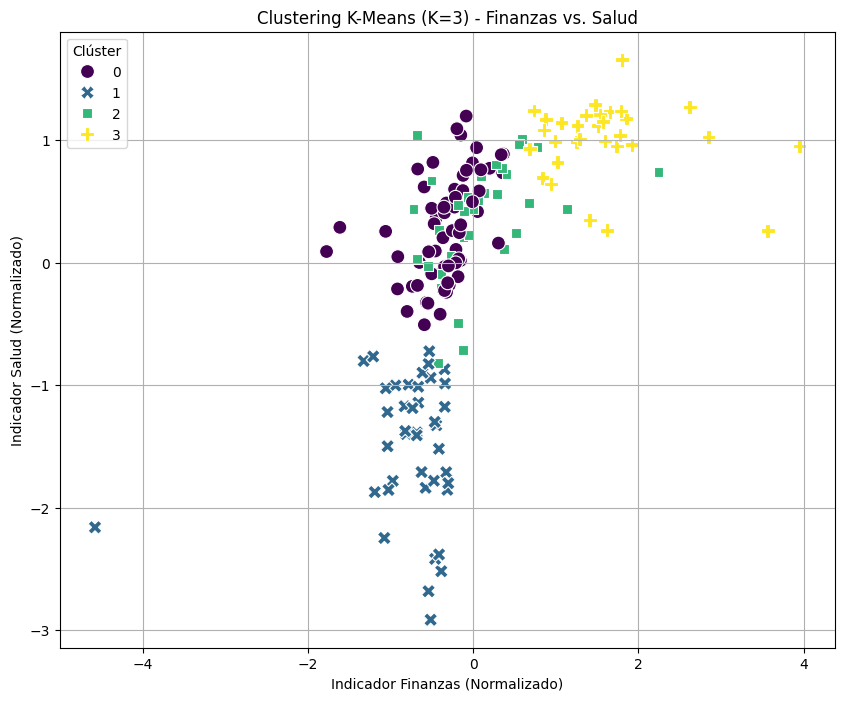

In [26]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='finanzas', 
    y='salud', 
    hue='Cluster', 
    data=indicadores_escalados, 
    palette='viridis', 
    style='Cluster', 
    s=100
)
plt.title('Clustering K-Means (K=3) - Finanzas vs. Salud')
plt.xlabel('Indicador Finanzas (Normalizado)')
plt.ylabel('Indicador Salud (Normalizado)')
plt.legend(title='Clúster')
plt.grid(True)
plt.show()

In [27]:
fig_3d = px.scatter_3d(
    indicadores_escalados, 
    x='finanzas', 
    y='salud', 
    z='comercio', 
    color='Cluster', 
    symbol='Cluster', 
    title='Clustering K-Means (K=3) en 3D'
)

fig_3d.update_layout(
    scene = dict(
        xaxis_title='Finanzas',
        yaxis_title='Salud',
        zaxis_title='Comercio'
    )
)
fig_3d.show()

### Evaluación de la agrupación

Como se ha observado en las visualizaciones anteriores, los tres clústers muestran una agrupación robusta y funcional, la combinación de un coeficiente de silueta aceptable y una separación visual clara en el gráfico 3D demuestra que el modelo ha logrado capturar patrones subyacentes en los datos que distinguen eficazmente los diferentes niveles de desarrollo de los países.

## 5 Análisis de resultados y conclusión del problema.

**Ejercicio 4**: Interpretar y explicar los resultados obtenidos en base a nuestro problema concreto.

* Desde la ONG se tiene conocimiento de que las variables más representativas para decidir si un país necesita o no ayuda son el ingreso neto (income) y la mortalidad infantil (child_mort). Dibuja un boxplot de ambas variables respecto a los clústeres etiquetados para determinar el nivel de ayuda para cada uno de los diferentes grupos. **Nota**: Si hemos obtenido dos clústers finales, los niveles de ayuda serán (necesita ayuda/no necesita ayuda), si son 3 (no necesita ayuda / necesita ayuda moderada/ necesita mucha ayuda) y así sucesivamente.

*   Utilizando la librería *kaileido* y *plotly.express* **dibuja un mapa mundi** dónde se refleje el nivel de ayuda necesario por país en función de los clústeres realizados. Que cada nivel de ayuda (clúster) tenga un color diferente.


*   **Conclusiones**: En función de nuestro análisis, ¿qué países debería priorizar Ayuda Internacional para depositar su ayuda y sus recursos? ¿Qué mejoras o implementaciones podríamos hacer a este análisis para mejorar sus resultados? Razona las respuestas de manera argumentada.

/tmp/ipykernel_38531/963169529.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_38531/963169529.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




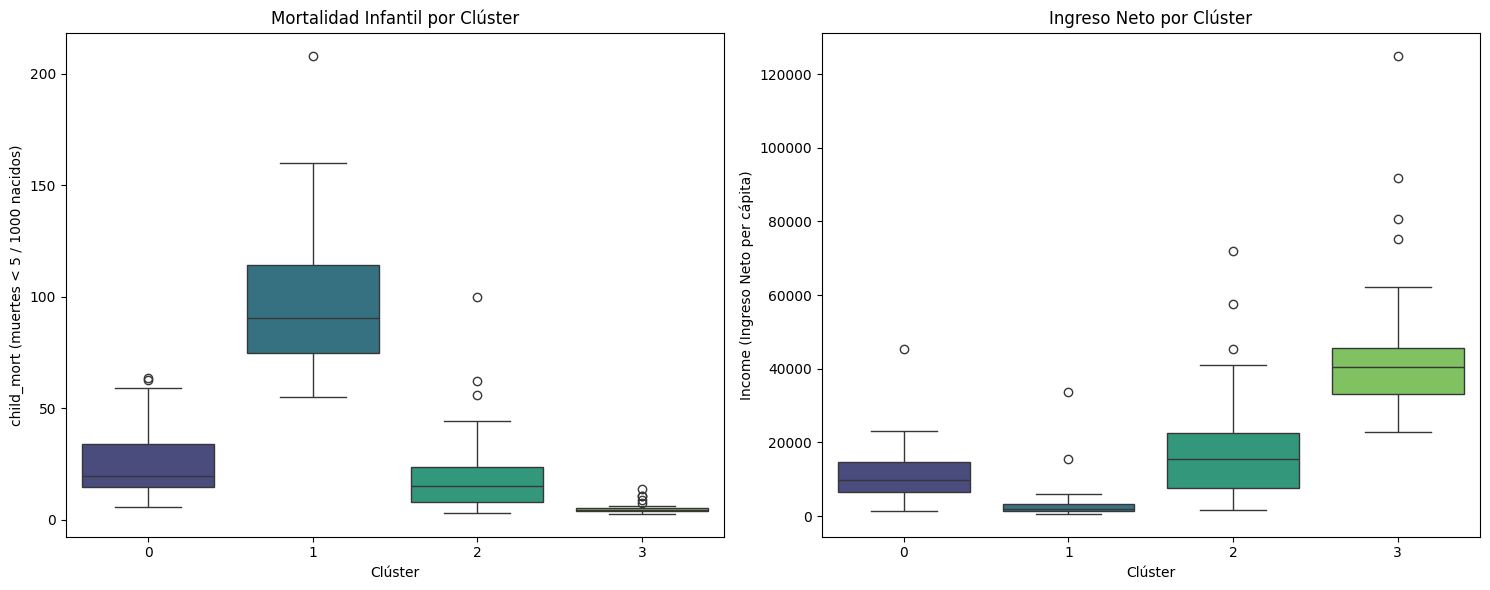

In [28]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='child_mort', data=df, palette='viridis')
plt.title('Mortalidad Infantil por Clúster')
plt.ylabel('child_mort (muertes < 5 / 1000 nacidos)')
plt.xlabel('Clúster')

plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='income', data=df, palette='viridis')
plt.title('Ingreso Neto por Clúster')
plt.ylabel('Income (Ingreso Neto per cápita)')
plt.xlabel('Clúster')

plt.tight_layout()
plt.show()

En el primer boxplot se pueden diferenciar claramente los 4 clústers, ya que en función de la mortalidad infantil tenemos el cluster 1 donde los valores son más altos que correspondería con el tercer mundo (concretamente los países que necesitan ayuda humanitaria urgente), el cluster 3 donde la mortalidad infantil es casi nula, correspondiente al primer mundo, el clúster 2, donde la mortalidad infantil existe pero es baja, correspondiente a países en vías de desarrollo, y el clúster 0, donde existe mortalidad infantil preocupante, pero no tanto como en 1, que correspondería con el tercer mundo.

Por otra parte, en el segundo boxplot se observa cómo el tercer clúster posee los ingresos más altos, con valores atípicos gigantes que indican una distribución de la riqueza global asimétrica. Por otra parte, se encuentran los clústers 1 y 0, que señalan los niveles de pobreza más alta respectivamente en términos de ingresos, y luego el clúster 2, que está relacionado con los países emergentes, que siguen siendo bajos en relación con el primer mundo.

In [29]:
# Calculo las medias para entender qué clúster es cual
cluster_means = df.groupby('Cluster')[['child_mort', 'income']].mean().reset_index()

# Ordeno por mortalidad infantil (de menor a mayor)
#    Menor mortalidad = Menos necesidad de ayuda
#    Mayor mortalidad = Más necesidad de ayuda
cluster_means = cluster_means.sort_values('child_mort')

# Mapeo de las etiquetas para K=4
etiquetas_ordenadas = [
    'No necesita ayuda', 
    'Necesita poca ayuda',
    'Necesita ayuda moderada', 
    'Necesita mucha ayuda'
]

# Creo diccionario de mapeo dinámico
mapping = { 
    cluster: etiqueta 
    for cluster, etiqueta in zip(cluster_means['Cluster'], etiquetas_ordenadas) 
}

# Aplico el mapeo al DataFrame
df['Nivel_Ayuda'] = df['Cluster'].map(mapping)


# Creo el mapa
fig_map = px.choropleth(
    df,
    locations='country',
    locationmode='country names',
    color='Nivel_Ayuda',
    hover_name='country',
    # Asigno colores para no dar lugar a confusión
    color_discrete_map={
        'No necesita ayuda': 'green',
        'Necesita poca ayuda': 'yellow',
        'Necesita ayuda moderada': 'orange',
        'Necesita mucha ayuda': 'red'
    },
    # Ordeno la leyenda
    category_orders={
        'Nivel_Ayuda': etiquetas_ordenadas
    },
    title='Mapa Mundial de Prioridad de Ayuda (Ayuda Internacional) - 4 Clústeres',
    projection='natural earth'
)

fig_map.show()

# Guardar imagen (opcional)
fig_map.write_image("mapa_mundi_final_k4.png", engine="kaleido")

/tmp/ipykernel_38531/3390370946.py:28: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



/tmp/ipykernel_38531/3390370946.py:52: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




### Conclusiones

El objetivo del trabajo fue clasificar los países mediante el uso de indicadores socioeconómicos y de salud que reducían la dimensionalidad de el dataset, para identificar aquellas regiones que requieren un mayor nivel de ayuda humanitaria. Estos indicadores fueron aquellos relacionados con salud, comercio y finanzas, que posteriormente fueron estandarizados para asegurar comparabilidad entre ellos.

Tras la evaluación de los distintos valores de K que podía tomar nuestra agrupación, que fue realizada empleando el método del codo, el coficiente de Silhouette y Gap Statistics para diferentes valores experimentales de K, se seleccionó finalmente el valor K = 4, ya que ofrecía una segmentación clara y estable, diferenciando no solo al primer mundo de los países en vías de desarrollo, sino los subgrupos del tercer mundo, donde dentro de esos valores extremos de pobreza existen niveles de urgencia humanitaria.

Para el análisis posterior, se emplearon dos variables clave para la ONG, la mortalidad infantil y el ingreso neto, que mostraron diferencias muy significativas entre los grupos, permitiendo así asignar un nivel de ayuda a cada clúster según estos valores promedio.

Al observar el mapa en la imagen anterior, se han segmentado los países en cuatro grupos claros basados en sus indicadores socioeconómicos y de salud. Atendiendo a esto, se han clasificado los mismos en función de su nivel de ayuda, que he dividido en los siguientes:
- Grupo prioritario ("Necesita mucha ayuda"): Esta agrupación de países presenta un alto índice de mortalidad infantil y unos niveles de ingresos muy bajos, como se observó en los boxplot, donde la media de mortalidad es superior a otros grupos y sus indicadores económicos se sitúan en los más desfavorables. Basándonos en la gravedad de lo mencionado dichos países deberían recibir ayuda humanitaria urgente, por lo que deberían recibir máxima prioridad. Estos países como se puede observar en el mapa generado corresponden con la África subsahariana, central, Madagascar, Yemen y algunos países de Asia central/sur.
- Grupo intermedio ("Ayuda moderada"): Países en vías de desarrollo con economías emergentes, donde la mortalidad infantil está controlada a pesar de no ser óptima y con ingresos bastante bajos, aunque superiores a los del grupo más vulnerable.
- Grupo en transición ("Necesita poca ayuda"): Incluye países con niveles de ingreso medio-alto, mortalidad infantil baja y sistemas sociales en proceso de consolidación. No requieren ayuda urgente, pero podrían beneficiarse de intervenciones puntuales.
- Grupo desarrollado ("No necesita ayuda"): Estos países no requieren de ningún tipo de ayuda, ya que su nivel de ingresos es muy alto, la actividad económica es muy amplia, la esperanza de vida es alta y la mortalidad infantil es casi nula.

### Posibles mejoras

Una mejora identificada es que para reducir la dimensionalidad del dataset se han empleado indicadores a través de la suma y resta de las variables originales basándose en la intuición económica, es un enfoque bastante subjetivo y no gestiona la fuerte correlación entre variables como la renta per cápita y los ingresos.

Como se ha visto en otras asignaturas del máster, el análisis de componentes principales (PCA) juega un papel importante en la reducción de la dimensionalidad de forma objetiva, ya que se apoya exclusivamente en la varianza matemática real de los datos y crea componentes que capturan la máxima información posible de forma objetiva.

Por otro lado, dado que la decisión final implica asignar recursos humanitarios con un impacto potencialmente elevado, sería recomendable incorporar un mayor número de variables y contrastes de información. Aunque indicadores como la mortalidad infantil son fundamentales, otras variables proporcionarían una visión más completa de las condiciones reales de cada país. Además, confiar únicamente en ingresos per cápita puede resultar engañoso, ya que no refleja diferencias en el coste de vida ni en la distribución de recursos dentro del propio país.